[NOTE](https://docs.google.com/document/d/1lX6JaKgWaKEq6y0KF2rAqxAVqHMdwpP8jZVIisrt74M/edit?usp=sharing)

# **ALNS + Deep Q-Learning**

## **Load Datasets from Kaggle**

In [1]:
import kagglehub
import shutil
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("senju14/vrptw-benchmark-datasets")
target_dir = '/content/vrptw-benchmark'

if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

shutil.copytree(path, target_dir)

'/content/vrptw-benchmark'

In [2]:
base_path = '/content/vrptw-benchmark/data/Solomon'

In [3]:
def load_solomon_instance(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    name = lines[0].strip()
    capacity = float(lines[4].split()[1])

    data = []
    for line in lines[9:]:
        if line.strip():
            data.append(list(map(float, line.split())))

    return {
        'name': name,
        'file': os.path.basename(file_path),
        'capacity': capacity,
        'data': np.array(data),
        'n_customers': len(data) - 1
    }

def load_dataset_group(pattern):
    files = sorted(glob.glob(os.path.join(base_path, pattern)))
    return [load_solomon_instance(f) for f in files]

rc1_dataset = load_dataset_group('rc1*.txt')
rc2_dataset = load_dataset_group('rc2*.txt')

print(f"Loaded {len(rc1_dataset)} RC1 instances, {len(rc2_dataset)} RC2 instances")

Loaded 8 RC1 instances, 8 RC2 instances


In [4]:
import os

with open(os.path.join(base_path, 'rc101.txt'), 'r') as f:
    print(f.read())

RC101

VEHICLE
NUMBER     CAPACITY
  25         200

CUSTOMER
CUST NO.   XCOORD.    YCOORD.    DEMAND   READY TIME   DUE DATE   SERVICE TIME
 
    0      40         50          0          0        240          0   
    1      25         85         20        145        175         10   
    2      22         75         30         50         80         10   
    3      22         85         10        109        139         10   
    4      20         80         40        141        171         10   
    5      20         85         20         41         71         10   
    6      18         75         20         95        125         10   
    7      15         75         20         79        109         10   
    8      15         80         10         91        121         10   
    9      10         35         20         91        121         10   
   10      10         40         30        119        149         10   
   11       8         40         40         59         89        

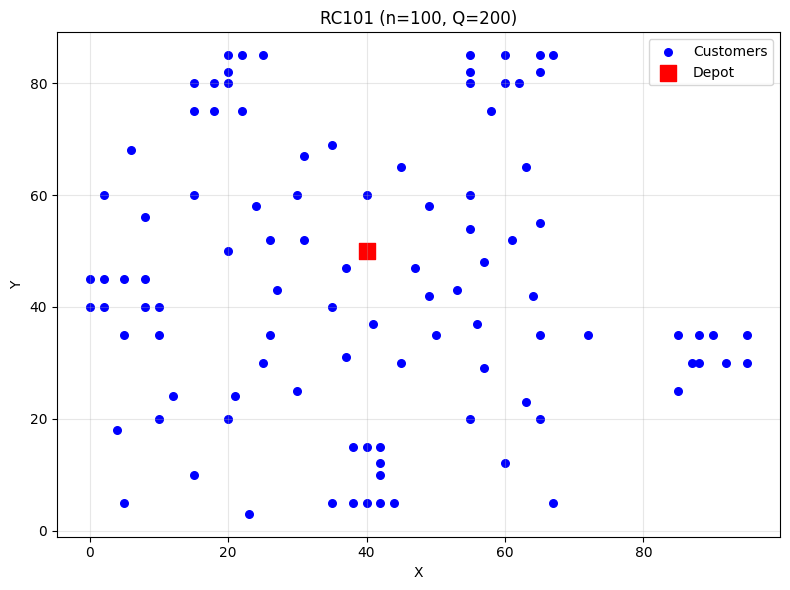

In [5]:
def visualize_instance(instance):
    data = instance['data']
    depot = data[0, 1:3]
    customers = data[1:, 1:3]

    plt.figure(figsize=(8, 6))
    plt.scatter(customers[:, 0], customers[:, 1], c='blue', s=30, label='Customers')
    plt.scatter(depot[0], depot[1], c='red', marker='s', s=120, label='Depot')
    plt.title(f"{instance['name']} (n={instance['n_customers']}, Q={instance['capacity']:.0f})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_instance(rc1_dataset[0])

## **Utils**

In [6]:
import numpy as np
from typing import List, Tuple

class VRPTWInstance:
    def __init__(self, instance_dict):
        self.name = instance_dict['name']
        self.capacity = instance_dict['capacity']
        self.data = instance_dict['data']
        self.n = len(self.data) - 1

        self.coords = self.data[:, 1:3]
        self.demands = self.data[:, 3]
        self.ready_times = self.data[:, 4]
        self.due_times = self.data[:, 5]
        self.service_times = self.data[:, 6]

        self.dist_matrix = self._compute_distances()

    def _compute_distances(self):
        coords = self.coords
        diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
        return np.sqrt(np.sum(diff**2, axis=2))

    def distance(self, i, j):
        return self.dist_matrix[i, j]

class Solution:
    def __init__(self, routes: List[List[int]], instance: VRPTWInstance):
        self.routes = routes
        self.instance = instance
        self.cost = self._compute_cost()
        self.feasible = self._check_feasibility()

    def _compute_cost(self):
        total = 0
        for route in self.routes:
            if len(route) == 0:
                continue
            total += self.instance.distance(0, route[0])
            for i in range(len(route) - 1):
                total += self.instance.distance(route[i], route[i+1])
            total += self.instance.distance(route[-1], 0)
        return total

    def _check_feasibility(self):
        inst = self.instance
        for route in self.routes:
            if sum(inst.demands[i] for i in route) > inst.capacity:
                return False

            time = 0
            current = 0
            for node in route:
                time += inst.distance(current, node)
                time = max(time, inst.ready_times[node])
                if time > inst.due_times[node]:
                    return False
                time += inst.service_times[node]
                current = node
        return True

    def copy(self):
        return Solution([r[:] for r in self.routes], self.instance)

    def __repr__(self):
        return f"Solution(routes={len(self.routes)}, cost={self.cost:.2f}, feasible={self.feasible})"

def compute_route_metrics(route: List[int], instance: VRPTWInstance) -> Tuple[float, float, bool]:
    if not route:
        return 0, 0, True

    load = sum(instance.demands[i] for i in route)

    distance = instance.distance(0, route[0])
    for i in range(len(route) - 1):
        distance += instance.distance(route[i], route[i+1])
    distance += instance.distance(route[-1], 0)

    time = 0
    current = 0
    feasible = load <= instance.capacity

    for node in route:
        time += instance.distance(current, node)
        time = max(time, instance.ready_times[node])
        if time > instance.due_times[node]:
            feasible = False
        time += instance.service_times[node]
        current = node

    return distance, load, feasible

## **Algorithms**

### **ALNS (Baseline)**

In [7]:
import numpy as np
import random
from typing import List

class ALNS:
    def __init__(self, instance: VRPTWInstance, max_iterations=1000,
                 destroy_size=0.3, temp_start=100, temp_decay=0.99):
        self.instance = instance
        self.max_iterations = max_iterations
        self.destroy_size = int(destroy_size * instance.n)
        self.temp = temp_start
        self.temp_decay = temp_decay

        self.destroy_ops = [self.random_removal, self.worst_removal, self.shaw_removal]
        self.repair_ops = [self.greedy_insert, self.regret_insert]

        self.destroy_weights = np.ones(len(self.destroy_ops))
        self.repair_weights = np.ones(len(self.repair_ops))

    def solve(self, initial_solution: Solution = None):
        if initial_solution is None:
            current = self._create_initial_solution()
        else:
            current = initial_solution.copy()

        best = current.copy()

        for iteration in range(self.max_iterations):
            destroy_idx = self._select_operator(self.destroy_weights)
            repair_idx = self._select_operator(self.repair_weights)

            removed = self.destroy_ops[destroy_idx](current.copy())
            candidate = self.repair_ops[repair_idx](removed)

            if self._accept(current, candidate):
                current = candidate
                if candidate.feasible and candidate.cost < best.cost:
                    best = candidate.copy()

            self.temp *= self.temp_decay

        return best

    def _create_initial_solution(self):
        inst = self.instance
        unvisited = list(range(1, inst.n + 1))
        routes = []

        while unvisited:
            route = []
            load = 0
            time = 0
            current = 0

            while unvisited:
                feasible_nodes = []
                for node in unvisited:
                    if load + inst.demands[node] <= inst.capacity:
                        arrival = time + inst.distance(current, node)
                        if arrival <= inst.due_times[node]:
                            feasible_nodes.append(node)

                if not feasible_nodes:
                    break

                next_node = min(feasible_nodes, key=lambda n: inst.distance(current, n))
                route.append(next_node)
                unvisited.remove(next_node)

                load += inst.demands[next_node]
                time += inst.distance(current, next_node)
                time = max(time, inst.ready_times[next_node])
                time += inst.service_times[next_node]
                current = next_node

            if route:
                routes.append(route)

        return Solution(routes, inst)

    def _select_operator(self, weights):
        probs = weights / weights.sum()
        return np.random.choice(len(weights), p=probs)

    def _accept(self, current: Solution, candidate: Solution):
        if not candidate.feasible:
            return False
        if candidate.cost < current.cost:
            return True
        delta = candidate.cost - current.cost
        return random.random() < np.exp(-delta / self.temp)

    def random_removal(self, solution: Solution):
        nodes_to_remove = random.sample(range(1, self.instance.n + 1),
                                       min(self.destroy_size, self.instance.n))
        removed = []
        for route in solution.routes:
            solution.routes[solution.routes.index(route)] = [n for n in route if n not in nodes_to_remove]
        solution.routes = [r for r in solution.routes if r]
        return solution, nodes_to_remove

    def worst_removal(self, solution: Solution):
        costs = []
        for route in solution.routes:
            for i, node in enumerate(route):
                prev = route[i-1] if i > 0 else 0
                next_node = route[i+1] if i < len(route)-1 else 0
                cost_before = self.instance.distance(prev, node) + self.instance.distance(node, next_node)
                cost_after = self.instance.distance(prev, next_node)
                costs.append((cost_before - cost_after, node))

        costs.sort(reverse=True)
        nodes_to_remove = [node for _, node in costs[:self.destroy_size]]

        for route in solution.routes:
            solution.routes[solution.routes.index(route)] = [n for n in route if n not in nodes_to_remove]
        solution.routes = [r for r in solution.routes if r]
        return solution, nodes_to_remove

    def shaw_removal(self, solution: Solution):
        all_nodes = [n for route in solution.routes for n in route]
        if not all_nodes:
            return solution, []

        seed = random.choice(all_nodes)
        nodes_to_remove = [seed]

        while len(nodes_to_remove) < self.destroy_size:
            relatedness = []
            for node in all_nodes:
                if node not in nodes_to_remove:
                    dist = self.instance.distance(seed, node)
                    time_diff = abs(self.instance.ready_times[seed] - self.instance.ready_times[node])
                    demand_diff = abs(self.instance.demands[seed] - self.instance.demands[node])
                    relatedness.append((dist + time_diff * 0.1 + demand_diff * 0.1, node))

            if not relatedness:
                break
            relatedness.sort()
            nodes_to_remove.append(relatedness[0][1])

        for route in solution.routes:
            solution.routes[solution.routes.index(route)] = [n for n in route if n not in nodes_to_remove]
        solution.routes = [r for r in solution.routes if r]
        return solution, nodes_to_remove

    def greedy_insert(self, partial_solution_with_removed):
        solution, removed_nodes = partial_solution_with_removed
        inst = self.instance

        for node in removed_nodes:
            best_cost = float('inf')
            best_position = None
            best_route_idx = None

            for route_idx, route in enumerate(solution.routes):
                for pos in range(len(route) + 1):
                    prev = route[pos-1] if pos > 0 else 0
                    next_node = route[pos] if pos < len(route) else 0

                    cost = (inst.distance(prev, node) + inst.distance(node, next_node)
                           - inst.distance(prev, next_node))

                    if cost < best_cost:
                        test_route = route[:pos] + [node] + route[pos:]
                        _, load, feasible = compute_route_metrics(test_route, inst)
                        if feasible:
                            best_cost = cost
                            best_position = pos
                            best_route_idx = route_idx

            if best_route_idx is not None:
                solution.routes[best_route_idx].insert(best_position, node)
            else:
                solution.routes.append([node])

        return Solution(solution.routes, inst)

    def regret_insert(self, partial_solution_with_removed):
        solution, removed_nodes = partial_solution_with_removed
        inst = self.instance

        while removed_nodes:
            best_regret = -float('inf')
            best_node = None
            best_insert = None

            for node in removed_nodes:
                costs = []
                for route_idx, route in enumerate(solution.routes):
                    for pos in range(len(route) + 1):
                        prev = route[pos-1] if pos > 0 else 0
                        next_node = route[pos] if pos < len(route) else 0

                        cost = (inst.distance(prev, node) + inst.distance(node, next_node)
                               - inst.distance(prev, next_node))

                        test_route = route[:pos] + [node] + route[pos:]
                        _, load, feasible = compute_route_metrics(test_route, inst)
                        if feasible:
                            costs.append((cost, route_idx, pos))

                if len(costs) >= 2:
                    costs.sort()
                    regret = costs[1][0] - costs[0][0]
                    if regret > best_regret:
                        best_regret = regret
                        best_node = node
                        best_insert = costs[0]
                elif len(costs) == 1:
                    if best_node is None:
                        best_node = node
                        best_insert = costs[0]

            if best_node is not None and best_insert is not None:
                _, route_idx, pos = best_insert
                solution.routes[route_idx].insert(pos, best_node)
                removed_nodes.remove(best_node)
            else:
                for node in removed_nodes:
                    solution.routes.append([node])
                break

        return Solution(solution.routes, inst)

### **DQN**

In [8]:

import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import time
import pandas as pd
from safetensors.torch import save_file, load_file

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.network(x)

class DQNAgent:
    def __init__(self, instance: VRPTWInstance, max_episodes=500,
                 epsilon_start=1.0, epsilon_end=0.1, buffer_size=10000, batch_size=64):
        self.instance = instance
        self.max_episodes = max_episodes
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / max_episodes

        self.state_dim = 9
        self.action_dim = instance.n + 1

        self.q_network = QNetwork(self.state_dim, self.action_dim)
        self.target_network = QNetwork(self.state_dim, self.action_dim)
        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.001)
        self.replay_buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.gamma = 0.99

    def get_state(self, current_node, visited, current_load, current_time):
        inst = self.instance
        route_state = [current_load / inst.capacity, current_time / 1000.0, len(visited) / inst.n]

        unvisited = [i for i in range(1, inst.n + 1) if i not in visited]
        feasible_count = sum(1 for n in unvisited
                           if current_load + inst.demands[n] <= inst.capacity)

        context = [(inst.capacity - current_load) / inst.capacity,
                   len(unvisited) / inst.n,
                   feasible_count / max(len(unvisited), 1),
                   inst.coords[current_node, 0] / 100.0,
                   inst.coords[current_node, 1] / 100.0,
                   inst.demands[current_node] / inst.capacity]

        return np.array(route_state + context, dtype=np.float32)

    def get_feasible_actions(self, current_node, visited, current_load, current_time):
        inst = self.instance
        actions = [0]

        for node in range(1, inst.n + 1):
            if node not in visited:
                if current_load + inst.demands[node] <= inst.capacity:
                    arrival = current_time + inst.distance(current_node, node)
                    if arrival <= inst.due_times[node]:
                        actions.append(node)
        return actions

    def select_action(self, state, feasible_actions):
        if random.random() < self.epsilon:
            return random.choice(feasible_actions)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            q_values = self.q_network(state_tensor).squeeze().numpy()

            feasible_q = [(q_values[a], a) for a in feasible_actions]
            return max(feasible_q)[1]

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(np.array(actions))
        rewards = torch.FloatTensor(np.array(rewards))
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(np.array(dones))

        current_q = self.q_network(states).gather(1, actions.unsqueeze(1))
        next_q = self.target_network(next_states).max(1)[0].detach()
        target_q = rewards + self.gamma * next_q * (1 - dones)

        loss = nn.MSELoss()(current_q.squeeze(), target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def solve(self):
        best_solution = None
        best_cost = float('inf')

        for episode in range(self.max_episodes):
            routes = []
            visited = set()

            while len(visited) < self.instance.n:
                route = []
                current_node = 0
                current_load = 0
                current_time = 0

                while True:
                    state = self.get_state(current_node, visited, current_load, current_time)
                    feasible = self.get_feasible_actions(current_node, visited, current_load, current_time)

                    if len(feasible) == 1:
                        break

                    action = self.select_action(state, feasible)

                    if action == 0:
                        break

                    route.append(action)
                    visited.add(action)

                    distance_added = self.instance.distance(current_node, action)
                    reward = -distance_added

                    current_load += self.instance.demands[action]
                    current_time += distance_added
                    current_time = max(current_time, self.instance.ready_times[action])
                    current_time += self.instance.service_times[action]

                    next_state = self.get_state(action, visited, current_load, current_time)
                    done = len(visited) == self.instance.n

                    self.replay_buffer.append((state, action, reward, next_state, done))
                    self.train_step()

                    current_node = action

                if route:
                    routes.append(route)

            solution = Solution(routes, self.instance)
            if solution.feasible and solution.cost < best_cost:
                best_cost = solution.cost
                best_solution = solution

            self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)

            if episode % 10 == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())

        return best_solution

### **DQN + ALNS**

In [9]:
class DQNALNSAgent:
    def __init__(self, instance: VRPTWInstance, max_episodes=500,
                 epsilon_start=1.0, epsilon_end=0.1):
        self.instance = instance
        self.max_episodes = max_episodes
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = (epsilon_start - epsilon_end) / max_episodes

        self.n_destroy = 3
        self.n_repair = 2
        self.action_dim = self.n_destroy * self.n_repair
        self.state_dim = 8

        self.q_network = QNetwork(self.state_dim, self.action_dim)
        self.target_network = QNetwork(self.state_dim, self.action_dim)
        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.001)
        self.replay_buffer = deque(maxlen=10000)
        self.batch_size = 64
        self.gamma = 0.99

        self.alns = ALNS(instance, max_iterations=1)

    def get_state(self, solution: Solution):
        inst = self.instance
        n_routes = len(solution.routes)
        avg_route_length = np.mean([len(r) for r in solution.routes]) if solution.routes else 0

        loads = [sum(inst.demands[i] for i in r) for r in solution.routes]
        avg_load = np.mean(loads) if loads else 0
        load_std = np.std(loads) if loads else 0

        times = []
        for route in solution.routes:
            t = 0
            curr = 0
            for node in route:
                t += inst.distance(curr, node)
                t = max(t, inst.ready_times[node])
                t += inst.service_times[node]
                curr = node
            times.append(t)
        avg_time = np.mean(times) if times else 0

        return np.array([
            solution.cost,
            n_routes,
            avg_route_length,
            avg_load,
            load_std,
            avg_time,
            inst.capacity,
            inst.n
        ])

    def select_operator_pair(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            q_values = self.q_network(state_tensor).squeeze()
            return q_values.argmax().item()

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(np.array(actions))
        rewards = torch.FloatTensor(np.array(rewards))
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(np.array(dones))

        current_q = self.q_network(states).gather(1, actions.unsqueeze(1))
        next_q = self.target_network(next_states).max(1)[0].detach()
        target_q = rewards + self.gamma * next_q * (1 - dones)

        loss = nn.MSELoss()(current_q.squeeze(), target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def solve(self):
        current = self.alns._create_initial_solution()
        best = current.copy()

        for episode in range(self.max_episodes):
            state = self.get_state(current)
            action_idx = self.select_operator_pair(state)

            destroy_idx = action_idx // self.n_repair
            repair_idx = action_idx % self.n_repair

            temp_sol = current.copy()
            removed = self.alns.destroy_ops[destroy_idx](temp_sol)
            candidate = self.alns.repair_ops[repair_idx](removed)

            reward = current.cost - candidate.cost if candidate.feasible else -100

            if candidate.feasible:
                if candidate.cost < current.cost or random.random() < 0.1:
                    current = candidate
                    if candidate.cost < best.cost:
                        best = candidate.copy()

            next_state = self.get_state(current)
            done = episode == self.max_episodes - 1

            self.replay_buffer.append((state, action_idx, reward, next_state, done))
            self.train_step()

            self.epsilon = max(self.epsilon_end, self.epsilon - self.epsilon_decay)

            if episode % 10 == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())

        return best

## **Run**

In [10]:
def run_experiments(rc1_dataset, rc2_dataset, n_runs=3):
    results = {
        'ALNS': {'rc1': [], 'rc2': []},
        'DQN': {'rc1': [], 'rc2': []},
        'DQN+ALNS': {'rc1': [], 'rc2': []}
    }

    for dataset_name, dataset in [('rc1', rc1_dataset), ('rc2', rc2_dataset)]:
        for inst_dict in dataset:
            print(f"Running {inst_dict['name']}...")
            instance = VRPTWInstance(inst_dict)

            run_results = {'ALNS': [], 'DQN': [], 'DQN+ALNS': []}

            for run in range(n_runs):
                start = time.time()
                alns = ALNS(instance, max_iterations=500)
                sol = alns.solve()
                alns_time = time.time() - start
                run_results['ALNS'].append({
                    'n_vehicles': len(sol.routes),
                    'cost': sol.cost,
                    'time': alns_time
                })

                start = time.time()
                dqn = DQNAgent(instance, max_episodes=500)
                sol = dqn.solve()
                dqn_time = time.time() - start
                run_results['DQN'].append({
                    'n_vehicles': len(sol.routes),
                    'cost': sol.cost,
                    'time': dqn_time
                })
                save_file(dqn.q_network.state_dict(), f'dqn_{inst_dict["name"]}.safetensors')

                start = time.time()
                dqn_alns = DQNALNSAgent(instance, max_episodes=500)
                sol = dqn_alns.solve()
                dqn_alns_time = time.time() - start
                run_results['DQN+ALNS'].append({
                    'n_vehicles': len(sol.routes),
                    'cost': sol.cost,
                    'time': dqn_alns_time
                })
                save_file(dqn_alns.q_network.state_dict(), f'dqn_alns_{inst_dict["name"]}.safetensors')

            for model in ['ALNS', 'DQN', 'DQN+ALNS']:
                avg_nv = np.mean([r['n_vehicles'] for r in run_results[model]])
                avg_cost = np.mean([r['cost'] for r in run_results[model]])
                avg_time = np.mean([r['time'] for r in run_results[model]])

                results[model][dataset_name].append({
                    'instance': inst_dict['name'],
                    'n_vehicles': avg_nv,
                    'cost': avg_cost,
                    'time': avg_time
                })

    return results

In [11]:
def create_results_table(results):
    table_data = []

    for model in ['ALNS', 'DQN', 'DQN+ALNS']:
        rc1_nv = np.mean([r['n_vehicles'] for r in results[model]['rc1']])
        rc1_cost = np.mean([r['cost'] for r in results[model]['rc1']])
        rc1_time = np.mean([r['time'] for r in results[model]['rc1']])

        rc2_nv = np.mean([r['n_vehicles'] for r in results[model]['rc2']])
        rc2_cost = np.mean([r['cost'] for r in results[model]['rc2']])
        rc2_time = np.mean([r['time'] for r in results[model]['rc2']])

        table_data.append({
            'Model': model,
            'RC1_NV': f'{rc1_nv:.1f}',
            'RC1_TD': f'{rc1_cost:.1f}',
            'RC1_Time': f'{rc1_time:.1f}s',
            'RC2_NV': f'{rc2_nv:.1f}',
            'RC2_TD': f'{rc2_cost:.1f}',
            'RC2_Time': f'{rc2_time:.1f}s'
        })

    df = pd.DataFrame(table_data)
    return df

In [12]:
results = run_experiments(rc1_dataset, rc2_dataset, n_runs=1)
df = create_results_table(results)
print(df)

Running RC101...
Running RC102...
Running RC103...
Running RC104...
Running RC105...
Running RC106...
Running RC107...
Running RC108...
Running RC201...
Running RC202...
Running RC203...
Running RC204...
Running RC205...
Running RC206...
Running RC207...
Running RC208...
      Model RC1_NV  RC1_TD RC1_Time RC2_NV  RC2_TD RC2_Time
0      ALNS   13.9  1446.8   116.0s    5.5  1040.0   219.8s
1       DQN   36.6  4027.0   164.3s   18.9  4373.3   165.6s
2  DQN+ALNS   14.2  1439.3   146.6s    6.1  1038.4   282.5s


In [13]:
'''
      Model RC1_NV  RC1_TD RC1_Time RC2_NV  RC2_TD RC2_Time
0      ALNS   13.6  1440.5   131.6s    5.6  1034.2   240.1s
1       DQN   34.9  4083.1   169.4s   19.2  4355.7   162.7s
2  DQN+ALNS   14.2  1446.7   164.3s    5.8  1033.3   319.5s
'''

'\n      Model RC1_NV  RC1_TD RC1_Time RC2_NV  RC2_TD RC2_Time\n0      ALNS   13.6  1440.5   131.6s    5.6  1034.2   240.1s\n1       DQN   34.9  4083.1   169.4s   19.2  4355.7   162.7s\n2  DQN+ALNS   14.2  1446.7   164.3s    5.8  1033.3   319.5s\n'

## **Visualization**

In [14]:
def visualize_solution(solution: Solution, title="Solution"):
    inst = solution.instance
    depot = inst.coords[0]

    plt.figure(figsize=(12, 8))

    colors = plt.cm.Set3(np.linspace(0, 1, len(solution.routes)))

    for idx, route in enumerate(solution.routes):
        route_coords = [depot] + [inst.coords[i] for i in route] + [depot]
        route_coords = np.array(route_coords)

        plt.plot(route_coords[:, 0], route_coords[:, 1],
                marker='o', linewidth=2, markersize=6,
                color=colors[idx], label=f'Route {idx+1}')

    plt.scatter(depot[0], depot[1], c='red', marker='s', s=200,
               label='Depot', zorder=5, edgecolors='black', linewidths=2)

    plt.title(f"{title}\nCost: {solution.cost:.2f}, Vehicles: {len(solution.routes)}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Inference**

In [15]:
def inference_with_vehicle_limit(model_path, instance_dict, max_vehicles):
    instance = VRPTWInstance(instance_dict)

    if 'dqn_alns' in model_path:
        agent = DQNALNSAgent(instance, max_episodes=100)
        state_dict = load_file(model_path)
        agent.q_network.load_state_dict(state_dict)
        agent.epsilon = 0.0
        solution = agent.solve()
    else:
        agent = DQNAgent(instance, max_episodes=100)
        state_dict = load_file(model_path)
        agent.q_network.load_state_dict(state_dict)
        agent.epsilon = 0.0
        solution = agent.solve()

    # Merge routes until <= max_vehicles
    while len(solution.routes) > max_vehicles:
        if len(solution.routes) <= 1:
            break

        # Find two smallest routes by load
        routes_with_idx = [(i, r, sum(instance.demands[n] for n in r))
                           for i, r in enumerate(solution.routes)]
        routes_with_idx.sort(key=lambda x: x[2])

        idx1, route1, _ = routes_with_idx[0]
        idx2, route2, _ = routes_with_idx[1]

        # Try merge
        merged = route1 + route2
        merged_load = sum(instance.demands[n] for n in merged)

        if merged_load > instance.capacity:
            print(f"Cannot merge further - capacity constraint violated")
            break

        new_routes = [r for i, r in enumerate(solution.routes)
                     if i not in [idx1, idx2]]
        new_routes.append(merged)

        test_solution = Solution(new_routes, instance)

        if not test_solution.feasible:
            print(f"Cannot merge further - time window violated")
            break

        solution = test_solution

    return solution

Cannot merge further - time window violated


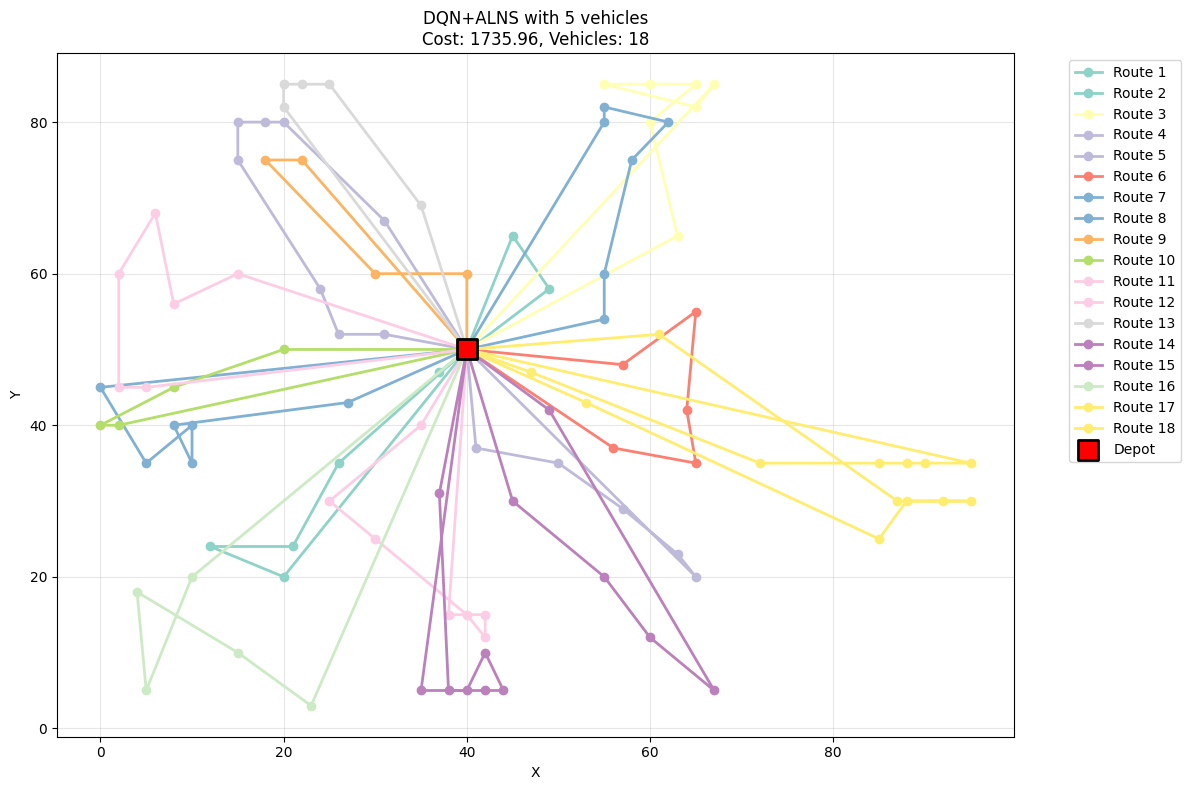

In [16]:
solution = inference_with_vehicle_limit('dqn_alns_RC101.safetensors', rc1_dataset[0], max_vehicles=5)
visualize_solution(solution, "DQN+ALNS with 5 vehicles")

Cannot merge further - time window violated


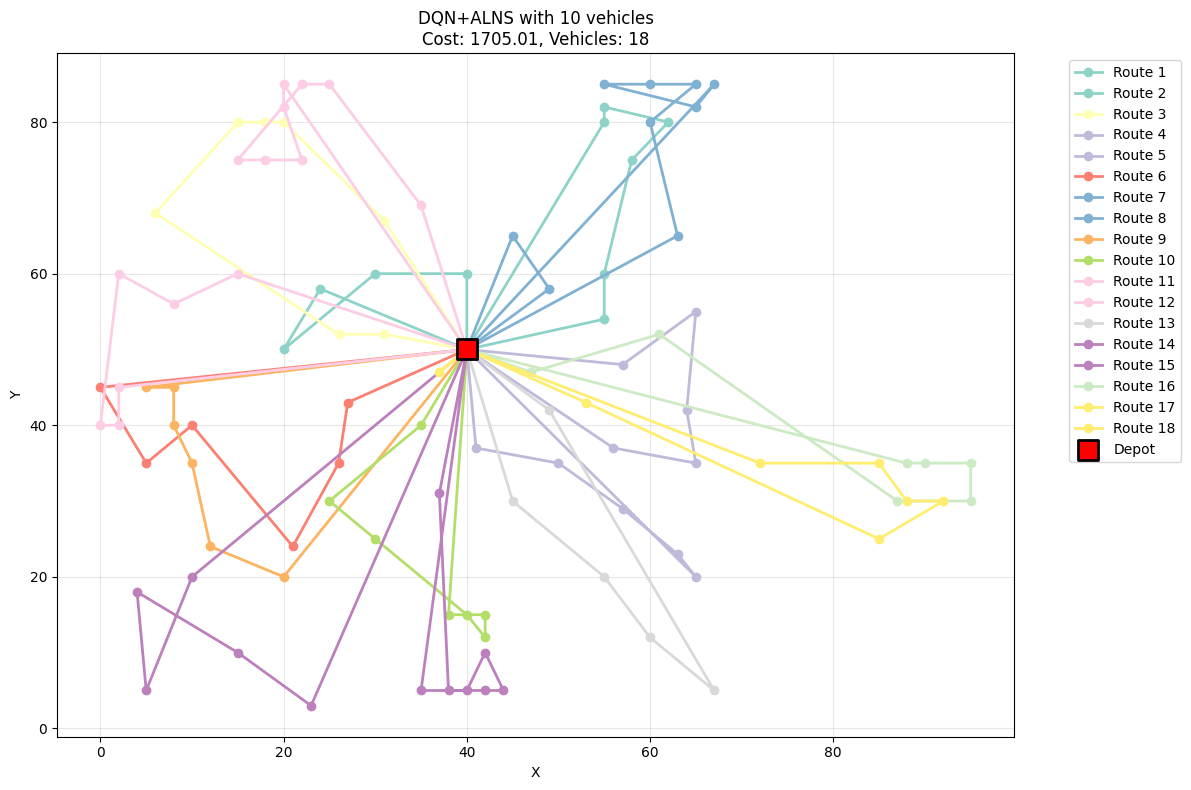

In [17]:
solution = inference_with_vehicle_limit('dqn_alns_RC101.safetensors', rc1_dataset[0], max_vehicles=10)
visualize_solution(solution, "DQN+ALNS with 10 vehicles")

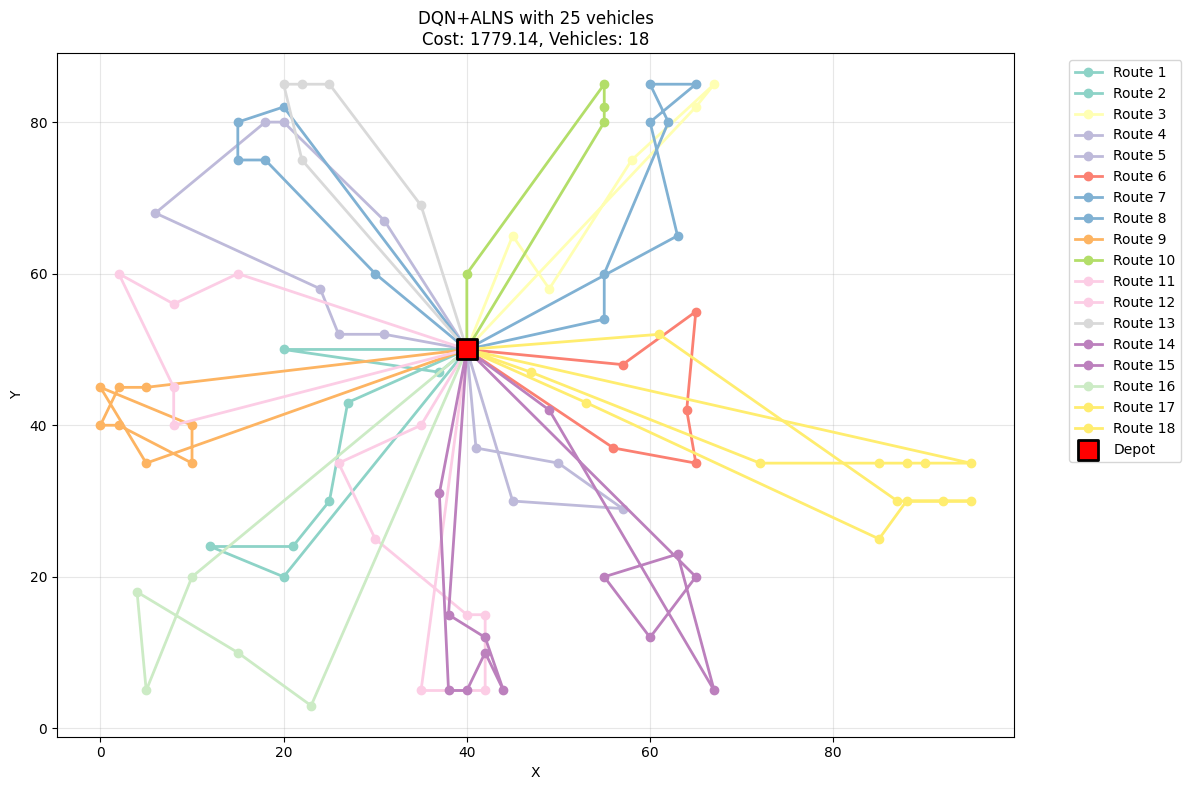

In [18]:
solution = inference_with_vehicle_limit('dqn_alns_RC101.safetensors', rc1_dataset[0], max_vehicles=25)
visualize_solution(solution, "DQN+ALNS with 25 vehicles")

**Kết quả này bình thường cho DQN trên VRPTW:**

**Tại sao DQN thua:**

- VRPTW phức tạp (capacity + time windows), DQN khó học policy tốt với 500 episodes
- State representation đơn giản (9 dims) thiếu context
- Exploration không đủ (epsilon 1.0→0.1 quá nhanh)
- ALNS có domain knowledge (destroy/repair heuristics), DQN học từ đầu

<br>

**DQN+ALNS cũng không tốt hơn vì:**

- Chỉ học chọn operator, không cải thiện operator quality
- 500 episodes quá ít để học operator selection tốt
- ALNS baseline đã tốt, khó cải thiện thêm

<br>

**Để DQN beat ALNS cần:**

- Attention/GNN encoder cho nodes
- 5000-10000 episodes training
- Pretrain trên nhiều instances
- Reward shaping tốt hơn
- Curriculum learning

<br>

Kết quả của bạn đúng - DQN không dễ thắng metaheuristics trên combinatorial optimization. Trong paper cũng thường DQN chỉ competitive sau khi train rất lâu.

## **Temp**

### **Base ALNS**

## **End**